In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(pROC))
suppressPackageStartupMessages(library(pheatmap))
suppressPackageStartupMessages(library(ggpubr))

Fig4A

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


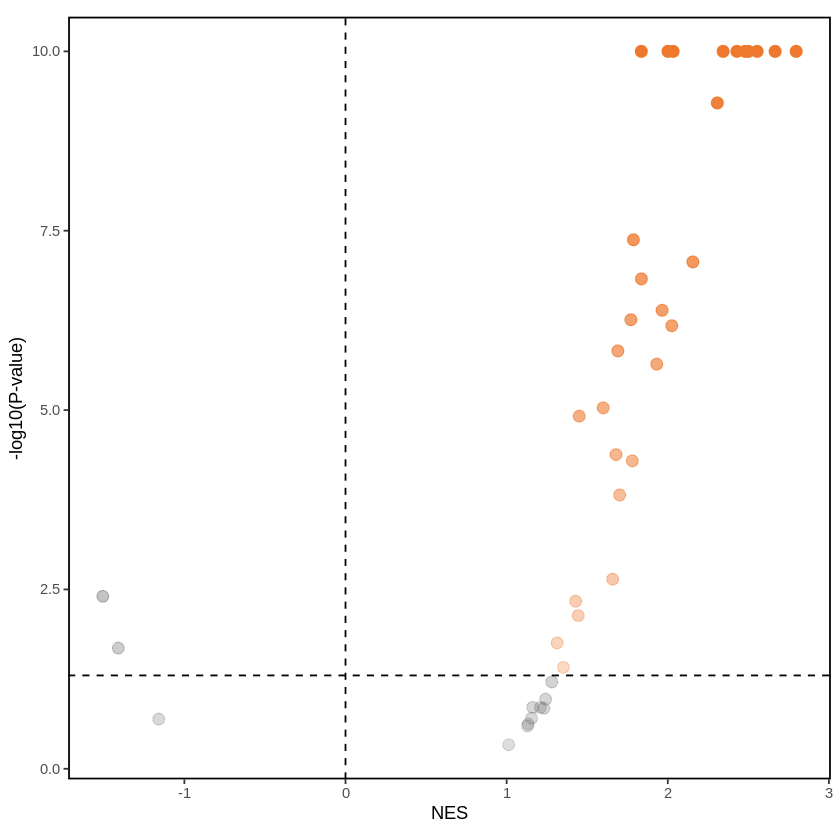

In [2]:
gsea_data = read.table('xxx/PaaSc_Data/Senescence/bulk_SenMayo_GSEA.tsv',header=T,sep='\t')
Fig4A_df <- gsea_data%>%mutate(Pvalue = -log10(p.adjust))%>%mutate(Label = ifelse(NES > 0 & Pvalue > -log10(0.05), "enriched", 'not enriched'))

Fig4A <- ggplot(Fig4A_df, aes(x = NES, y = Pvalue, color = Label, alpha = Pvalue)) +
          geom_point(size = 3) +
          scale_alpha_continuous(range = c(0.2, 1)) + 
          labs(x = "NES", y = "-log10(P-value)") +
          scale_color_manual(values = c("enriched" = "#ee792e", "not enriched" = "#5d5e5f")) +
          guides(color = "none", alpha = "none", fill = "none", size = "none") +
          theme_classic() +
          geom_vline(xintercept = 0, linetype = "dashed", color = "black") + 
          geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") + 
          theme(
                plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
                axis.line = element_blank(), 
                panel.border = element_rect(color = "black", fill = NA, size = 1),
                aspect.ratio = 1 
          )
Fig4A
ggsave(Fig4A,file='Fig4A.pdf',width = 6,height = 6,dpi = 300)

Fig4B

Warning message:
“`select_()` was deprecated in dplyr 0.7.0.
ℹ Please use `select()` instead.
ℹ The deprecated feature was likely used in the monocle package.
  Please report the issue to the authors.”


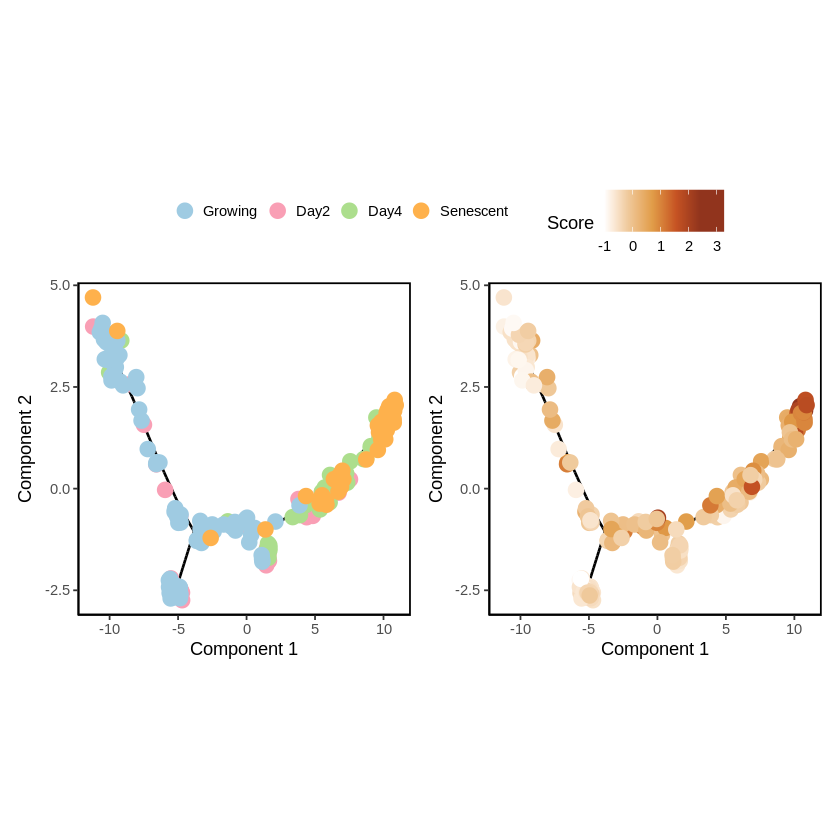

In [3]:
suppressPackageStartupMessages(library(monocle))
HSMM <- readRDS('xxx/PaaSc_Data/Senescence/GSE115301_Timecourse_monocle.RDS')
P_time_course <- plot_cell_trajectory(HSMM, color_by = "time_course", cell_size = 4) +      
                      scale_color_manual(values = c("#9fcbe2", "#f99fb5", "#acde8d", "#feb14c")) + 
                      guides(color = guide_legend(title = NULL)) + 
                      theme(aspect.ratio = 1,
                            legend.position = "top",  
                            legend.key.size = unit(0.5, "lines")
                  )
P_PaaSc <- plot_cell_trajectory(HSMM, color_by = "PaaSc", cell_size = 4) +      
              scale_color_gradientn(
                        colors = c('white', "#EFC99B", "#E19D49", "#C65323", "#91341D", "#91341D")) + 
              guides(color = guide_colorbar(title = "Score"), title.position = "left") + 
              theme(aspect.ratio = 1,
                    legend.position = "top",  
                    legend.key.size = unit(1, "lines")
              )
Fig4B=(P_time_course + P_PaaSc) + 
          plot_layout(ncol = 2, guides = "collect") & 
          theme(
                plot.background = element_blank(),  
                aspect.ratio = 1,
                panel.border = element_rect(color = "black", fill = NA, size = 1),  
                legend.position = "top"
          )
Fig4B
ggsave(Fig4B,file='Fig4B.pdf',width = 12,height = 6,dpi = 300)

Fig4C

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


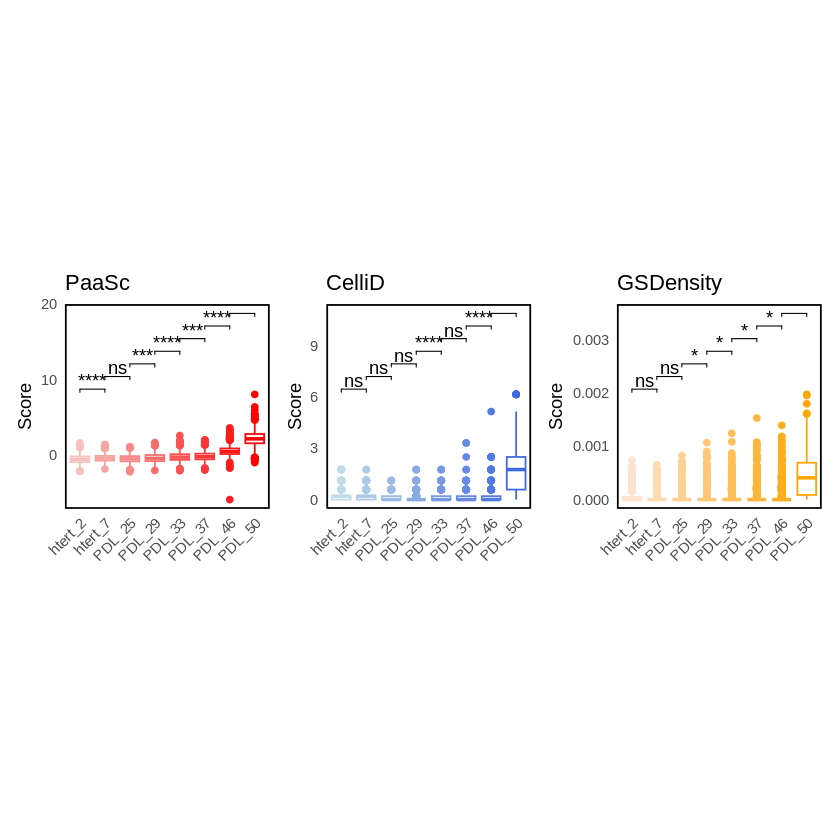

In [2]:
# load data
object = readRDS('xxx/PaaSc_Data/Senescence/GSE175533_WI38.RDS')
levels = c('htert_2', 'htert_7', 'PDL_25', 'PDL_29', 'PDL_33', 'PDL_37', 'PDL_46', 'PDL_50')
Fig4C_df <- read.table('xxx/PaaSc_Data/Senescence/GSE175533_Score.tsv') %>%
  mutate(PDL = factor(object@meta.data$PDL, levels = levels))

# Create a function to generate boxplot for each method
generate_boxplot <- function(df, method, colors) {
  ggplot(df, aes(x = PDL, y = !!sym(method), color = PDL)) + 
    geom_boxplot() +
    guides(fill = "none", color = "none")+
    scale_color_manual(values = colors) +
    labs(x = NULL, y = 'Score', title = method) +
    theme_minimal() +
    theme(
      aspect.ratio = 1,
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank()
    )+
  stat_compare_means(
    comparisons =  list(c('htert_2','htert_7'),c('htert_7', 'PDL_25'), c('PDL_25', 'PDL_29'), 
                       c('PDL_29', 'PDL_33'),  c('PDL_33', 'PDL_37'),c('PDL_37','PDL_46'),c('PDL_46', 'PDL_50')),  
    method = "wilcox.test",   
      method.args = list(alternative = "less"), 
    label = "p.signif")
}
FigPaaSc=generate_boxplot(Fig4C_df, 'PaaSc', colorRampPalette(c("#F5C2BE", "red"))(8)) 
FigCelliD=generate_boxplot(Fig4C_df, 'CelliD', colorRampPalette(c('#BFDAE9', 'royalblue'))(8))
FigGSDensity=generate_boxplot(Fig4C_df, 'GSDensity', colorRampPalette(c('#fee3ce', 'orange'))(8)) 
Fig4C<-(FigPaaSc + FigCelliD + FigGSDensity)
Fig4C
ggsave(Fig4C,file='Fig4C.pdf',width = 18,height = 6,dpi = 300)

Fig4D

In [5]:
# Create a function to generate ROC curves for each dataset
generate_roc_plot <- function(data, dataset_name) {
                        roc_data <- data.frame()
                        auc_values <- data.frame(Method = character(), AUC = numeric(), Dataset = character())
                        # Calculate ROC curves for each method
                        for (method in methods) {
                          roc_curve <- roc(data$Group, data[[method]])
                          roc_data <- rbind(roc_data, data.frame(
                            Method = method,
                            Specificity = 1 - roc_curve$specificities,
                            Sensitivity = roc_curve$sensitivities,
                            Dataset = dataset_name
                          ))
                          auc_values <- rbind(auc_values, data.frame(Method = method, AUC = auc(roc_curve), Dataset = dataset_name))
                        }
                        roc_data$Method = factor(roc_data$Method,level = c("PaaSc", "GSDensity", "CelliD"))

                        legend_labels <- paste(auc_values$Method, "- AUC =", sprintf("%0.3f", auc_values$AUC))
                        # Create the plot using ggplot
                        ggplot(roc_data, aes(x = Specificity, y = Sensitivity, color = Method)) +
                              geom_line(size = 1.2) +
                              theme_minimal() +
                              scale_color_manual(values = colors, labels = legend_labels) +
                              labs(
                                title = dataset_name,
                                x = "1 - Specificity",
                                y = "Sensitivity",
                                color = "Method") +
                              geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray") +
                              theme(
                                   legend.position = c(0.85, 0.15),   
                                   legend.justification = c(1, 0),    
                                    plot.background = element_blank(), 
                                    panel.border = element_rect(color = "black", fill = NA, size = 1), 
                                    panel.grid.major = element_blank(), 
                                    panel.grid.minor = element_blank(), 
                                    plot.title = element_text(hjust = 0.5), 
                                    legend.key.size = unit(1, "cm"),    
                                    legend.title = element_text(size = 10), 
                                    legend.text = element_text(size = 10)  
                                    ) +
                                    guides(color = guide_legend(ncol = 1,title = NULL))                          
}


Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”
Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing, case = Sen

Setting direction: controls < cases

Setting levels: control = Growing,

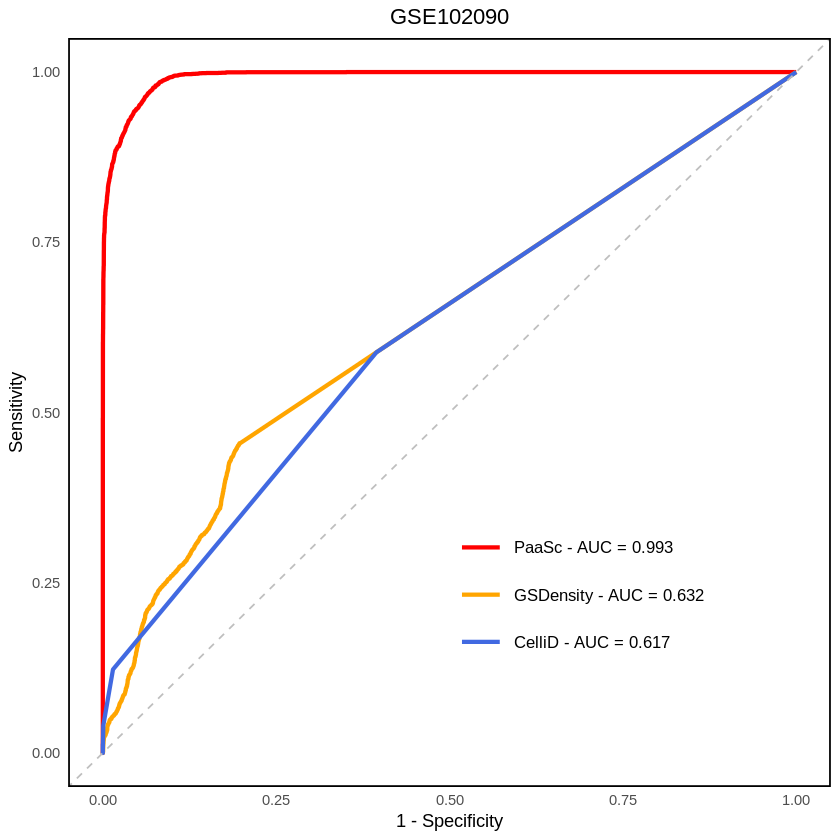

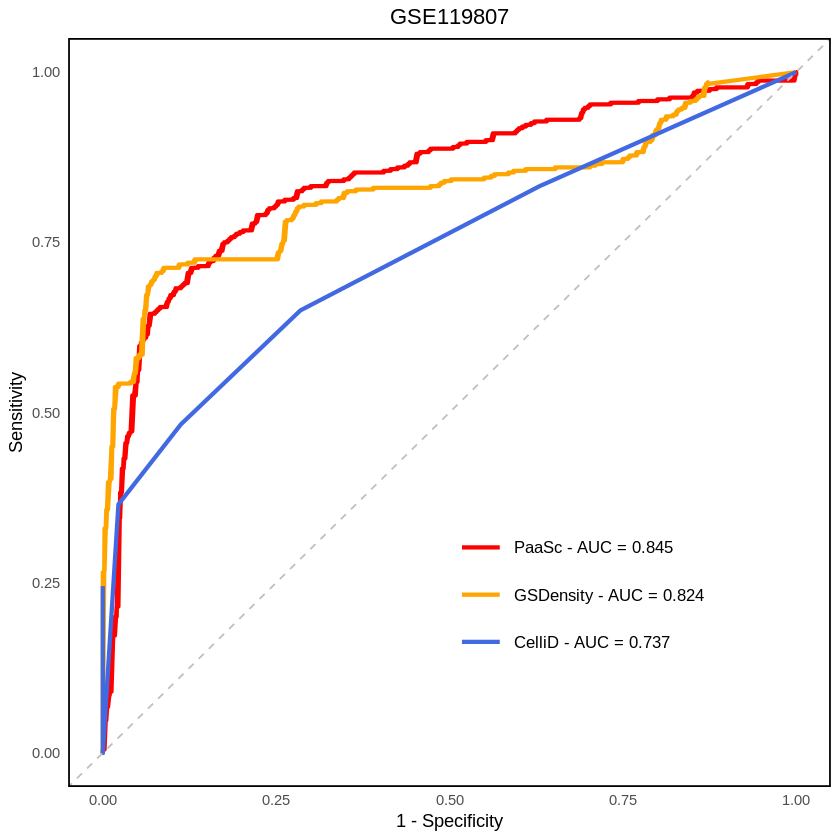

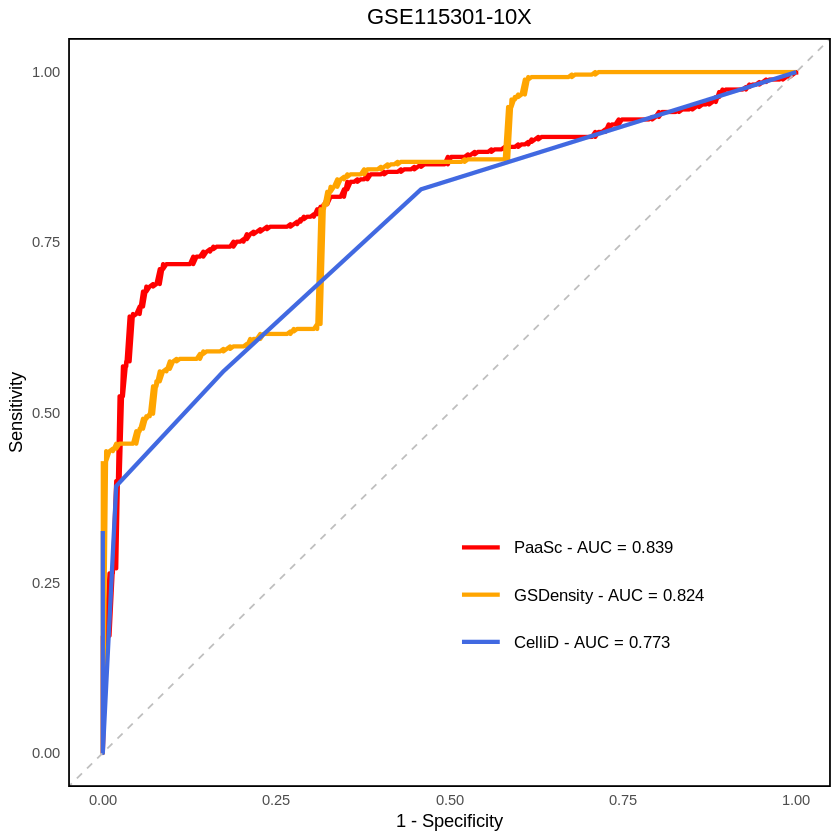

In [6]:
GSE115301_10X=read.table('xxx/PaaSc_Data/Senescence/GSE115301_10X_Score.tsv')
GSE119807=read.table('xxx/PaaSc_Data/Senescence/GSE119807_Score.tsv')
GSE102090=read.table('xxx/PaaSc_Data/Senescence/GSE102090_Score.tsv')

colors <- c("red", "orange", "royalblue")
methods <- c("PaaSc", "GSDensity", "CelliD")

plot_GSE115301_10X <- generate_roc_plot(GSE115301_10X, "GSE115301-10X")
plot_GSE119807 <- generate_roc_plot(GSE119807, "GSE119807")
plot_GSE102090 <- generate_roc_plot(GSE102090, "GSE102090")

plot_GSE102090 
plot_GSE119807 
plot_GSE115301_10X

Fig4D <- (plot_GSE102090 + plot_GSE119807 + plot_GSE115301_10X) + 
  theme(
    plot.background = element_blank(),  
    panel.border = element_rect(color = "black", fill = NA, size = 1)
  )
ggsave(Fig4D,file='Fig4D.pdf',width = 18,height = 6,dpi = 300)

Fig4E

`summarise()` has grouped output by 'hallmark'. You can override using the `.groups` argument.


pdf 
  2

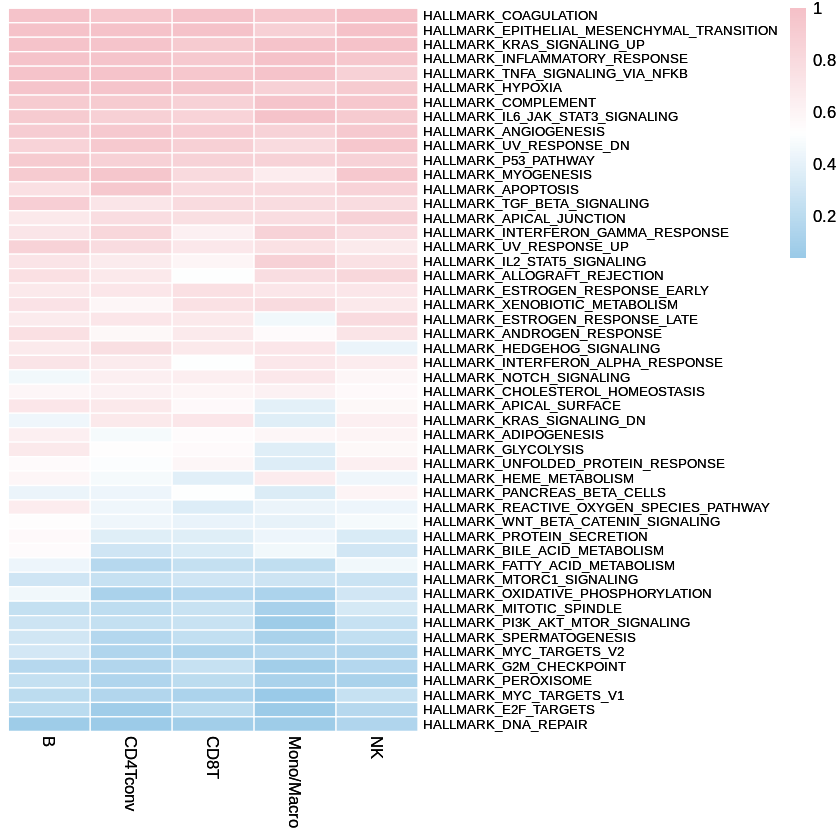

In [7]:
correlation_df=read.table('xxx/PaaSc_Data/Senescence/all_pid_celltype_hallmarkVSsene_correlation.tsv',sep='\t',header=T)
correlation_df$padj=p.adjust(correlation_df$pvalue,method='fdr')
correlation_df = correlation_df %>%
  group_by(hallmark, celltype) %>%
  summarise(
    cor_pos_pvalue_count = n_distinct(pid[cor > 0.2 & padj < 0.05]),  # cor > 0 且 pvalue < 0.05 的 pid 数量
    cor_neg_pvalue_count = n_distinct(pid[cor < -0.2 & padj < 0.05])   # cor < 0 且 pvalue < 0.05 的 pid 数量
  ) %>%ungroup()%>%
    mutate(pos_percentage=cor_pos_pvalue_count/(cor_pos_pvalue_count+cor_neg_pvalue_count))%>%
    select(-c('cor_pos_pvalue_count','cor_neg_pvalue_count'))%>%
    pivot_wider(values_from = pos_percentage,names_from = celltype)%>%column_to_rownames(var='hallmark')

Fig4E_df <- correlation_df[order(apply(correlation_df, 1, mean), decreasing = TRUE), ]

colors = c('#9ACAE8','white','#F5C1C8')
Fig4E <- pheatmap(Fig4E_df, treeheight_row = 0,   # 不显示行聚类树状图
               cluster_cols = FALSE,  # 不显示列聚类
         cluster_rows = FALSE,
         treeheight_col = 0, 
         color = colorRampPalette(colors)(100),
         border_color = 'white',
         fontsize_row = 8)
Fig4E         
pdf('Fig4E.pdf',height = 12,width = 8)
Fig4E 
dev.off()